El Harraj Imane

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [65]:
def sigmoid(z):
    # transforme n'importe quelle valeur en probabilité entre 0 et 1
    # plus z est grand, plus on se rapproche de 1
    # plus z est petit (négatif), plus on se rapproche de 0
    return 1 / (1 + np.exp(-z))

In [66]:
def accuracy(y_true, y_pred):
    # calcule simplement le pourcentage de bonnes réponses
    return np.mean(y_true == y_pred)

In [67]:
# on génère des données artificielles pour tester le modèle
# 2 classes bien séparées dans un espace 2D
X, y = datasets.make_blobs(
    n_samples=150,
    n_features=2,
    centers=2,
    cluster_std=1.2,
    random_state=2
)

# on sépare les données :
# - train = pour apprendre
# - test = pour vérifier si le modèle généralise bien
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
lr = 0.01
n_iters = 1000
# nombre de features (ici 2 variables d'entrée)
n_features = X_train.shape[1]
# poids initialisés à zéro
W = np.zeros(n_features)
# biais initial (sert à déplacer la frontière)
b = 0
# nombre d'exemples
m = len(X_train)

In [69]:
for _ in range(n_iters):

    #1. on calcule la combinaison linéaire des entrées
    Z = np.dot(X_train, W) + b
    # on transforme en probabilité avec sigmoid
    A = sigmoid(Z)

    # 2. calcul de l'erreur (gradient simplifié du loss)
    dZ = A - y_train

    # 3. calcul du gradient des poids
    # on regarde l'impact de chaque feature sur l'erreur
    dW = np.dot(X_train.T, dZ) / m
    # gradient du biais (moyenne des erreurs)
    db = np.sum(dZ) / m

    # 4. mise à jour des paramètres
    # on corrige dans la direction qui réduit l'erreur
    W = W - lr * dW
    b = b - lr * db

In [70]:
# permet de prédire une classe pour de nouvelles données
def predict(X):
    # on calcule les probabilités
    probs = sigmoid(np.dot(X, W) + b)
    # on transforme en 0 ou 1 selon un seuil de 0.5
    return (probs >= 0.5).astype(int)

# on teste sur les données jamais vues
preds = predict(X_test)
print("accuracy:", accuracy(y_test, preds))

accuracy: 0.9


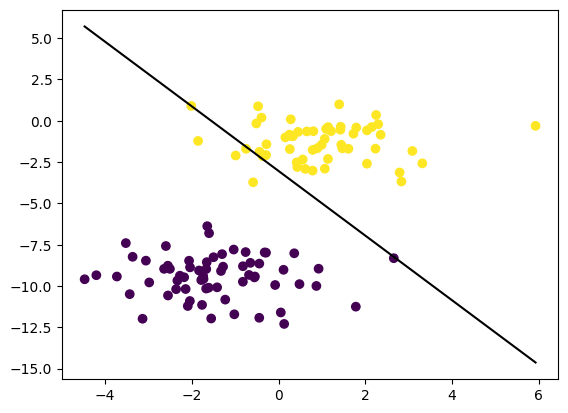

In [71]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

x0, x1 = np.min(X_train[:, 0]), np.max(X_train[:, 0])

if W[1] != 0:
    y0 = (-W[0] * x0 - b) / W[1]
    y1 = (-W[0] * x1 - b) / W[1]
    plt.plot([x0, x1], [y0, y1], "k")

plt.show()